# IMPORT DEPENDENCIES

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# DATA COLLECTION

In [2]:
train_data=pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/train.csv")
train_data

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,fd3dafe738fd,0.149555,3130.05946,123.763599,9.513984,13.020852,3.499305,0.077343,8.545512,2.804172,...,0.173229,1.26092,0.067730,8.967128,217.148554,8095.932828,24.640462,69.191944,21.978000,0
613,fd895603f071,0.435846,5462.03438,85.200147,46.551007,15.973224,5.979825,0.025882,12.622906,3.777550,...,10.223150,1.24236,0.426699,35.896418,496.994214,3085.308063,29.648928,124.808872,0.145340,0
614,fd8ef6377f76,0.427300,2459.10720,130.138587,55.355778,10.005552,8.070549,0.025578,15.408390,1.229900,...,0.173229,0.49706,0.067730,19.962092,128.896894,6474.652866,26.166072,119.559420,21.978000,0
615,fe1942975e40,0.363205,1263.53524,85.200147,23.685856,8.138688,7.981959,0.025578,7.524588,1.229900,...,9.256996,0.78764,0.670527,24.594488,72.611063,1965.343176,25.116750,37.155112,0.184622,0


# DATA ANALYSIS

In [3]:
x=train_data.copy()
x["EJ"]=x["EJ"].apply(lambda x:ord(x))
x=x.fillna(-1)

In [4]:
correlation=train_data.corr()

/tmp/ipykernel_20/3005766631.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation=train_data.corr()


<Axes: >

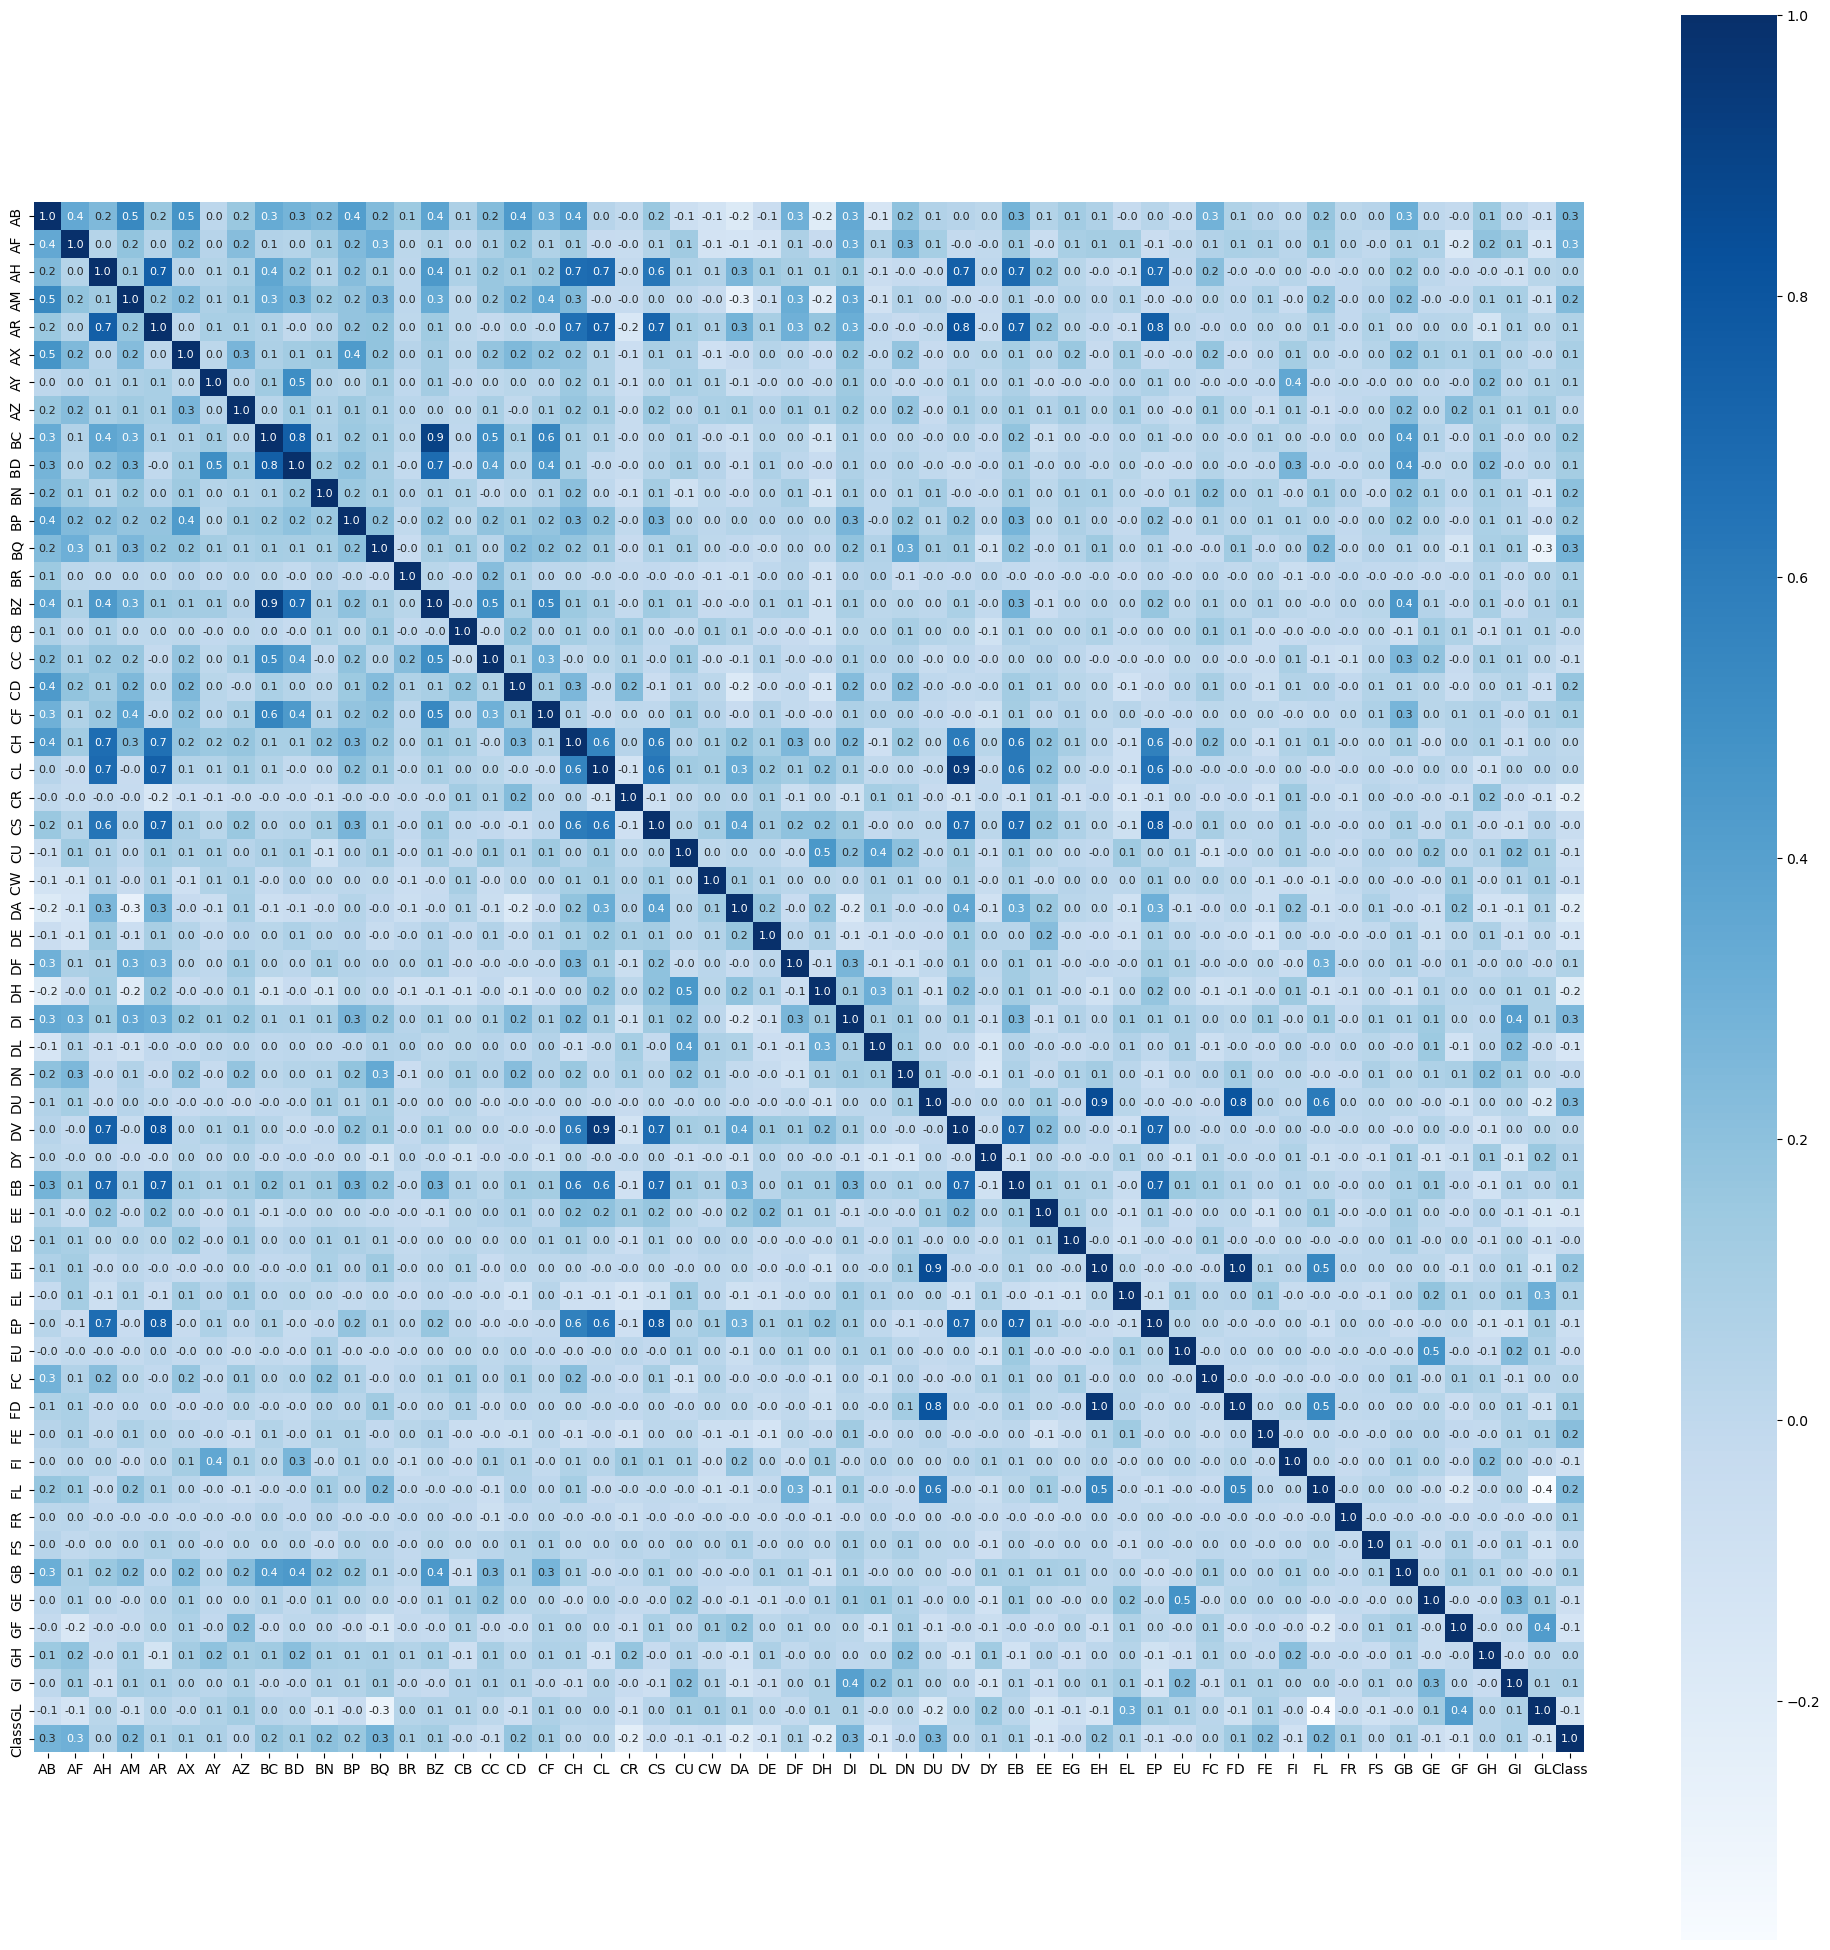

In [5]:
#constructing  a heat map to unjderstand correlation between columns
plt.figure(figsize=(25,25))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')
#datset=correlation 
#cbar is the bar on the r8 side 
#the boxes should b square
#fmt = floating point size 
#annot r the labels on left side 
#annot_kws = size of the labels
#cmap = colour 
#Darker colour = Directly Prop (+ve corr)
#Lighter colour = Inversely Prop (-ve corr)

In [6]:
["AH","AZ","CB","CH","CL","CS","DN","DV","EU","EG","FC","FS","GH"]

['AH', 'AZ', 'CB', 'CH', 'CL', 'CS', 'DN', 'DV', 'EU', 'EG', 'FC', 'FS', 'GH']

In [7]:
test_data=pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/test.csv")
test_data

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,00eed32682bb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,010ebe33f668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,02fa521e1838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,040e15f562a2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,046e85c7cc7f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
combined_data = pd.concat([pd.DataFrame(train_data), pd.DataFrame(test_data)])

combined_data["EJ"]=combined_data["EJ"].apply(lambda x:ord(x))

combined_data=combined_data.drop(["AH","AZ","CB","CH","CL","CS","DN","DV","EU","EG","FC","FS","GH"],axis=1)

combined_data=combined_data.fillna(-1)

train_encoded = combined_data.iloc[:len(train_data)]
test_encoded = combined_data.iloc[len(train_data):]
train_encoded

,Id,AB,AF,AM,AR,AX,AY,BC,BD,BN,...,FE,FI,FL,FR,GB,GE,GF,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,22.394407,8.138688,0.699861,0.025578,5.555634,4126.58731,22.5984,...,9028.291921,3.583450,7.298162,1.73855,11.339138,72.611063,2003.810319,69.834944,0.120343,1.0
1,007255e47698,0.145282,978.76416,36.968889,8.138688,3.632190,0.025578,1.229900,5496.92824,19.4205,...,6785.003474,10.358927,0.173229,0.49706,9.292698,72.611063,27981.562750,32.131996,21.978000,0.0
2,013f2bd269f5,0.470030,2635.10654,32.360553,8.138688,6.732840,0.025578,1.229900,5135.78024,26.4825,...,8338.906181,11.626917,7.709560,0.97556,37.077772,88.609437,13676.957810,35.192676,0.196941,0.0
3,043ac50845d5,0.252107,3819.65177,77.112203,8.138688,3.685344,0.025578,1.229900,4169.67738,23.6577,...,10965.766040,14.852022,6.122162,0.49706,18.529584,82.416803,2094.262452,90.493248,0.155829,0.0
4,044fb8a146ec,0.380297,3733.04844,14.103738,8.138688,3.942255,0.054810,102.151980,5728.73412,24.0108,...,16198.049590,13.666727,8.153058,48.50134,16.408728,146.109943,8524.370502,36.262628,0.096614,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,fd3dafe738fd,0.149555,3130.05946,9.513984,13.020852,3.499305,0.077343,2.804172,4157.68439,21.1860,...,17167.209610,9.879296,0.173229,1.26092,8.967128,217.148554,8095.932828,69.191944,21.978000,0.0
613,fd895603f071,0.435846,5462.03438,46.551007,15.973224,5.979825,0.025882,3.777550,5654.07556,27.1887,...,18460.330020,10.910227,10.223150,1.24236,35.896418,496.994214,3085.308063,124.808872,0.145340,0.0
614,fd8ef6377f76,0.427300,2459.10720,55.355778,10.005552,8.070549,0.025578,1.229900,5888.87769,20.4798,...,5088.922912,12.029366,0.173229,0.49706,19.962092,128.896894,6474.652866,119.559420,21.978000,0.0
615,fe1942975e40,0.363205,1263.53524,23.685856,8.138688,7.981959,0.025578,1.229900,4517.86560,19.0674,...,6464.250832,8.026928,9.256996,0.78764,24.594488,72.611063,1965.343176,37.155112,0.184622,0.0


In [9]:
x=train_encoded.drop(["Id","Class"],axis=1)
x

,AB,AF,AM,AR,AX,AY,BC,BD,BN,BP,...,FD,FE,FI,FL,FR,GB,GE,GF,GI,GL
0,0.209377,3109.03329,22.394407,8.138688,0.699861,0.025578,5.555634,4126.58731,22.5984,175.638726,...,10.265073,9028.291921,3.583450,7.298162,1.73855,11.339138,72.611063,2003.810319,69.834944,0.120343
1,0.145282,978.76416,36.968889,8.138688,3.632190,0.025578,1.229900,5496.92824,19.4205,155.868030,...,0.296850,6785.003474,10.358927,0.173229,0.49706,9.292698,72.611063,27981.562750,32.131996,21.978000
2,0.470030,2635.10654,32.360553,8.138688,6.732840,0.025578,1.229900,5135.78024,26.4825,128.988531,...,8.745201,8338.906181,11.626917,7.709560,0.97556,37.077772,88.609437,13676.957810,35.192676,0.196941
3,0.252107,3819.65177,77.112203,8.138688,3.685344,0.025578,1.229900,4169.67738,23.6577,237.282264,...,7.884336,10965.766040,14.852022,6.122162,0.49706,18.529584,82.416803,2094.262452,90.493248,0.155829
4,0.380297,3733.04844,14.103738,8.138688,3.942255,0.054810,102.151980,5728.73412,24.0108,324.546318,...,4.274640,16198.049590,13.666727,8.153058,48.50134,16.408728,146.109943,8524.370502,36.262628,0.096614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,0.149555,3130.05946,9.513984,13.020852,3.499305,0.077343,2.804172,4157.68439,21.1860,167.877117,...,0.296850,17167.209610,9.879296,0.173229,1.26092,8.967128,217.148554,8095.932828,69.191944,21.978000
613,0.435846,5462.03438,46.551007,15.973224,5.979825,0.025882,3.777550,5654.07556,27.1887,285.628059,...,6.067614,18460.330020,10.910227,10.223150,1.24236,35.896418,496.994214,3085.308063,124.808872,0.145340
614,0.427300,2459.10720,55.355778,10.005552,8.070549,0.025578,1.229900,5888.87769,20.4798,178.661133,...,0.296850,5088.922912,12.029366,0.173229,0.49706,19.962092,128.896894,6474.652866,119.559420,21.978000
615,0.363205,1263.53524,23.685856,8.138688,7.981959,0.025578,1.229900,4517.86560,19.0674,119.162529,...,6.192291,6464.250832,8.026928,9.256996,0.78764,24.594488,72.611063,1965.343176,37.155112,0.184622


In [10]:
y=train_encoded["Class"]
y

0      1.0
1      0.0
2      0.0
3      0.0
4      1.0
      ... 
612    0.0
613    0.0
614    0.0
615    0.0
616    0.0
Name: Class, Length: 617, dtype: float64

# TRAIN TEST SPLIT

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

In [12]:
print(y.shape,y_train.shape,y_test.shape)

(617,) (555,) (62,)


# MODEL TRAINING

In [13]:
'''
model=RandomForestClassifier(random_state=42) #loading the model
model.fit(x_train,y_train) #training the model
x_test_prediction=model.predict(x_test)
test_data_accuracy=accuracy_score(y_test,x_test_prediction)
print("ACCURACY = ",test_data_accuracy)
'''

'\nmodel=RandomForestClassifier(random_state=42) #loading the model\nmodel.fit(x_train,y_train) #training the model\nx_test_prediction=model.predict(x_test)\ntest_data_accuracy=accuracy_score(y_test,x_test_prediction)\nprint("ACCURACY = ",test_data_accuracy)\n'

In [14]:
# Fine-tuning XGBC using GridSearchCV
'''
xgbc_param_grid = {'learning_rate': [0.1, 0.01, 0.001],
                   'max_depth': [3, 5, 7],
                   'n_estimators': [100, 200, 300]}
xgbc_grid_search = GridSearchCV(XGBClassifier(objective='binary:logistic'), xgbc_param_grid, scoring='accuracy', cv=5)
xgbc_grid_search.fit(x_train, y_train)
xgbc_best_params = xgbc_grid_search.best_params_
model = xgbc_grid_search.best_estimator_
model.fit(x_train,y_train)
x_test_prediction=model.predict(x_test)
test_data_accuracy=accuracy_score(y_test,x_test_prediction)
print("ACCURACY = ",test_data_accuracy)
'''


'\nxgbc_param_grid = {\'learning_rate\': [0.1, 0.01, 0.001],\n                   \'max_depth\': [3, 5, 7],\n                   \'n_estimators\': [100, 200, 300]}\nxgbc_grid_search = GridSearchCV(XGBClassifier(objective=\'binary:logistic\'), xgbc_param_grid, scoring=\'accuracy\', cv=5)\nxgbc_grid_search.fit(x_train, y_train)\nxgbc_best_params = xgbc_grid_search.best_params_\nmodel = xgbc_grid_search.best_estimator_\nmodel.fit(x_train,y_train)\nx_test_prediction=model.predict(x_test)\ntest_data_accuracy=accuracy_score(y_test,x_test_prediction)\nprint("ACCURACY = ",test_data_accuracy)\n'

In [15]:

model=XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1,
              monotone_constraints='()', n_estimators=100, n_jobs=4,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)
model.fit(x_train,y_train)
x_test_prediction=model.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)
print("ACCURACY = ",test_data_accuracy)

ACCURACY =  0.9838709677419355


# BUILDING A PREDICTION SYSTEM

In [16]:
file=pd.read_csv("/kaggle/input/answeranswer/answer.csv")
file=file.drop(["Survived","PassengerId"],axis=1)
file

""


In [17]:
file["Id"]=test_encoded["Id"]
file

,Id
0,00eed32682bb
1,010ebe33f668
2,02fa521e1838
3,040e15f562a2
4,046e85c7cc7f


In [18]:
test_x=test_encoded.drop(["Id","Class"],axis=1)
test_x

,AB,AF,AM,AR,AX,AY,BC,BD,BN,BP,...,FD,FE,FI,FL,FR,GB,GE,GF,GI,GL
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
probability=model.predict_proba(test_x)

In [20]:
class_0=probability[:,0]
class_1=probability[:,1]

In [21]:
file["class_0"]=class_0 
file["class_1"]=class_1
file

,Id,class_0,class_1
0,00eed32682bb,0.981367,0.018633
1,010ebe33f668,0.981367,0.018633
2,02fa521e1838,0.981367,0.018633
3,040e15f562a2,0.981367,0.018633
4,046e85c7cc7f,0.981367,0.018633


In [22]:
file.to_csv("submission.csv",index=False) #update the answer.csv and save it as submission.csv 

In [23]:
x=pd.read_csv("/kaggle/working/submission.csv")
x

,Id,class_0,class_1
0,00eed32682bb,0.981367,0.018633
1,010ebe33f668,0.981367,0.018633
2,02fa521e1838,0.981367,0.018633
3,040e15f562a2,0.981367,0.018633
4,046e85c7cc7f,0.981367,0.018633
